In [12]:
!pip install torch torchvision matplotlib numpy

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

# DATA

transform = transforms.Compose([transforms.ToTensor()])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=256)

In [ ]:
# PRUNABLE LAYER
class PrunableLinear(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_f, in_f) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_f))

        # 🔥 slightly negative init
        self.gate_scores = nn.Parameter(torch.randn(out_f, in_f) - 1.5)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores * 1.5)  # balanced sharpening
        return F.linear(x, self.weight * gates, self.bias)

In [ ]:
# MODEL
class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

    def get_gates(self):
        gates = []
        for m in self.modules():
            if hasattr(m, "gate_scores"):
                g = torch.sigmoid(m.gate_scores * 1.5)
                gates.append(g.view(-1))
        return torch.cat(gates)

In [ ]:
# EVALUATE

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

In [ ]:
def run_experiment(lambda_val, epochs=20, threshold=0.5):
    model = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    print(f"\n--- Lambda: {lambda_val} ---")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            class_loss = criterion(outputs, labels)

            gates = model.get_gates()
            sparsity_loss = torch.mean(gates)

            # 🔥 gradual pruning
            current_lambda = lambda_val * (epoch / epochs)

            loss = class_loss + current_lambda * sparsity_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # calculate sparsity
        with torch.no_grad():
            g = model.get_gates()
            pruned = torch.sum(g < threshold).item()
            sparsity = (pruned / g.numel()) * 100

        print(f"Epoch {epoch+1} | Loss: {total_loss:.2f} | Sparsity: {sparsity:.2f}%")

    acc = evaluate(model, testloader)

    return {
        "lambda": lambda_val,
        "accuracy": acc,
        "sparsity": sparsity,
        "gates": g.cpu().numpy(),
        "model": model
    }

# =========================
# RUN (BALANCED TARGET)
# =========================
lambdas = [0.005, 0.01]

results = []
for l in lambdas:
    results.append(run_experiment(l))

# =========================
# RESULTS TABLE
# =========================
print("\nFINAL RESULTS")
for r in results:
    print(f"Lambda: {r['lambda']} | Acc: {r['accuracy']:.2f}% | Sparsity: {r['sparsity']:.2f}%")


--- Lambda: 0.005 ---
Epoch 1 | Loss: 801.92 | Sparsity: 93.20%
Epoch 2 | Loss: 724.82 | Sparsity: 93.20%
Epoch 3 | Loss: 682.93 | Sparsity: 93.23%
Epoch 4 | Loss: 655.60 | Sparsity: 93.29%
Epoch 5 | Loss: 635.64 | Sparsity: 93.36%
Epoch 6 | Loss: 617.18 | Sparsity: 93.45%
Epoch 7 | Loss: 602.95 | Sparsity: 93.56%
Epoch 8 | Loss: 588.61 | Sparsity: 93.67%
Epoch 9 | Loss: 576.41 | Sparsity: 93.79%
Epoch 10 | Loss: 566.22 | Sparsity: 93.92%
Epoch 11 | Loss: 556.76 | Sparsity: 94.07%
Epoch 12 | Loss: 547.83 | Sparsity: 94.23%
Epoch 13 | Loss: 538.27 | Sparsity: 94.38%
Epoch 14 | Loss: 532.31 | Sparsity: 94.55%
Epoch 15 | Loss: 524.48 | Sparsity: 94.72%
Epoch 16 | Loss: 517.97 | Sparsity: 94.89%
Epoch 17 | Loss: 510.85 | Sparsity: 95.06%
Epoch 18 | Loss: 504.81 | Sparsity: 95.23%
Epoch 19 | Loss: 498.36 | Sparsity: 95.39%
Epoch 20 | Loss: 492.60 | Sparsity: 95.56%

--- Lambda: 0.01 ---
Epoch 1 | Loss: 802.37 | Sparsity: 93.20%
Epoch 2 | Loss: 727.98 | Sparsity: 93.21%
Epoch 3 | Loss: 680.

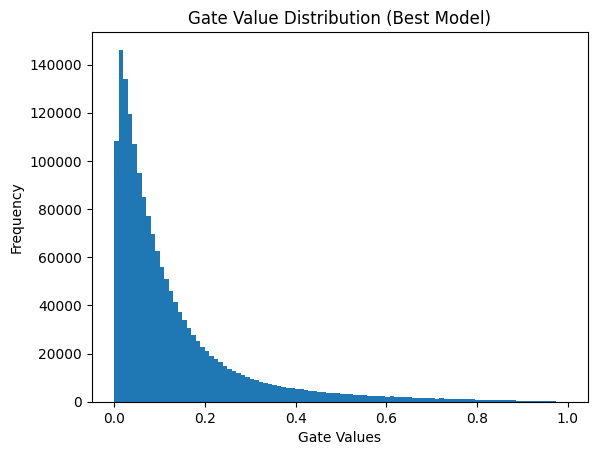

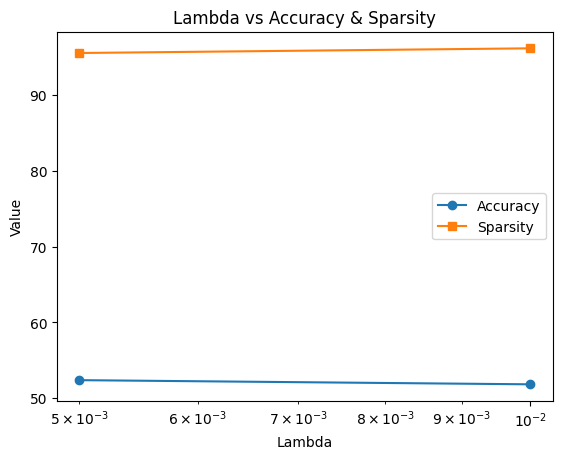

In [15]:
# GRAPH 1: GATE DISTRIBUTION
best = max(results, key=lambda x: x["sparsity"])

plt.figure()
plt.hist(best["gates"], bins=100)
plt.title("Gate Value Distribution (Best Model)")
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.show()

# GRAPH 2: LAMBDA vs PERFORMANCE

l_vals = [r["lambda"] for r in results]
accs = [r["accuracy"] for r in results]
sparsities = [r["sparsity"] for r in results]

plt.figure()
plt.plot(l_vals, accs, marker='o', label="Accuracy")
plt.plot(l_vals, sparsities, marker='s', label="Sparsity")
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Value")
plt.title("Lambda vs Accuracy & Sparsity")
plt.legend()
plt.show()